In [5]:
import sys
import pandas as pd
import os
import datetime
import argparse
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
dataset_name = 'BITCOIN'
path = rf'/raid/t2/TGN_adv/tspear/DATA/{dataset_name}'

os.listdir(path)

['ATTACKED', 'ext_full.pkl', 'edges.csv']

In [7]:
save_at = r'/raid/t2/TGN_adv/tspear/DATA/BITCOIN2'

In [8]:
df = pd.read_csv(os.path.join(path, 'edges.csv'))
df.head()

,Unnamed: 0,src,dst,time,label,idx,ext_roll
0,0,1,15,1.289243e+09,1.0,1,0
1,1,4,3,1.289245e+09,7.0,2,0
2,2,13,16,1.289254e+09,8.0,3,0
3,3,13,10,1.289254e+09,8.0,4,0
4,4,7,5,1.289363e+09,1.0,5,0


In [12]:
df.groupby(['src', 'dst']).first()

Unnamed: 0          time  label    idx  ext_roll
src  dst                                                   
1    2            252  1.296629e+09    8.0    253         0
     3           4987  1.308242e+09    6.0   4988         0
     4          11987  1.343107e+09   10.0  11988         0
     5             26  1.289711e+09    4.0     27         0
     6           4994  1.308242e+09    8.0   4995         0
...               ...           ...    ...    ...       ...
5994 5458       35466  1.445608e+09    1.0  35467         2
5995 35         35472  1.446130e+09    1.0  35473         2
5996 5949       35492  1.447008e+09    3.0  35493         2
5999 3878       35518  1.449651e+09    8.0  35519         2
6000 6002       35528  1.450279e+09    1.0  35529         2

[35590 rows x 5 columns]

In [41]:
random_row = df.sample(1)  # Randomly sample one row from the DataFrame
src, dst = random_row['src'].iloc[0], random_row['dst'].iloc[0]
print(src, dst)

df[(df['src'] == src) & (df['dst'] == dst)]['label'].unique()

35 3155


array([1.])

In [42]:
# Group by 'user_from' and 'user_to', count occurrences
interaction_counts = df.groupby(['src', 'dst']).size().reset_index(name='count')

# Display results
print(interaction_counts)

# Filter pairs with multiple ratings
multiple_ratings = interaction_counts[interaction_counts['count'] > 1]
print("\nUsers who rated multiple times:")
print(multiple_ratings)

        src   dst  count
0         1     2      1
1         1     3      1
2         1     4      1
3         1     5      1
4         1     6      1
...     ...   ...    ...
35585  5994  5458      1
35586  5995    35      1
35587  5996  5949      1
35588  5999  3878      1
35589  6000  6002      1

[35590 rows x 3 columns]

Users who rated multiple times:
Empty DataFrame
Columns: [src, dst, count]
Index: []


In [5]:
new_df = df.drop(columns=['label'], axis=1)
new_df.head()

,Unnamed: 0,src,dst,time,idx,ext_roll
0,0,1,15,1.289243e+09,1,0
1,1,4,3,1.289245e+09,2,0
2,2,13,16,1.289254e+09,3,0
3,3,13,10,1.289254e+09,4,0
4,4,7,5,1.289363e+09,5,0


In [6]:
# new_df.to_csv(os.path.join(save_at, 'edges.csv'), index=False)

In [7]:
new_df['time'] = new_df['time'].astype(int)
new_df.head()

,Unnamed: 0,src,dst,time,idx,ext_roll
0,0,1,15,1289243140,1,0
1,1,4,3,1289245277,2,0
2,2,13,16,1289254254,3,0
3,3,13,10,1289254300,4,0
4,4,7,5,1289362700,5,0


In [8]:
print(new_df['time'].min(), datetime.datetime.fromtimestamp(new_df['time'].min()), new_df['time'].max(), datetime.datetime.fromtimestamp(new_df['time'].max()))

datetime.datetime.fromtimestamp(new_df['time'].max()) - datetime.datetime.fromtimestamp(new_df['time'].min())

1289243140 2010-11-09 00:35:40 1453684323 2016-01-25 06:42:03


datetime.timedelta(days=1903, seconds=21983)

In [9]:
1903/365

5.213698630136986

In [16]:
from TEA_plots import load_continuous_edgelist, gen_plot_edge_dist

def plot_continuous_network(raw_path, network_name):
    print(f'Plotting {network_name}')
    raw_path = '/raid/t2/TGN_adv/tspear/DATA/' if raw_path is None else raw_path
    path = os.path.join(raw_path, network_name)
    if network_name.lower() in ['lastfm', 'enron', 'bitcoin']:
        print('switching to 30 day interval')
        interval_size = 86400 * 30  # one month
    elif network_name.lower() in [ 'uci', 'socialevolve']:
        print('switching to 5 day interval')
        interval_size = 86400 * 5  # 5 days
    else:
        print('switching to 1 day interval')
        interval_size = 86400  # one day
    
    if 'tspear' in raw_path:
        edgelist_filename = f'{path}/edges.csv'
    else:
        raise NotImplementedError('Please provide the path to the edgelist')
    temp_edgelist = load_continuous_edgelist(edgelist_filename, interval_size=interval_size)
    gen_plot_edge_dist(temp_edgelist, network_name, path, USLegis=False)

Plotting BITCOIN
switching to 30 day interval
Info: Interval size: 2592000
Loading edge-list: Maximum timestamp is  1453684323.75728
Loading edge-list: Maximum timestamp-bin-id is 560
Loading edge-list: Total number of edges: 35590
There are 64 timestamps.
INFO: Network Name: BITCOIN
INFO: AVG. stats. over all timestamps:  ts                            528.500000
new                           556.093750
repeated                        0.000000
not_repeated                20828.546875
total_curr_ts                 556.093750
total_seen_until_curr_ts    21384.640625
dtype: float64
INFO: ratio of avg.(new)/avg.(total_curr_ts): 1.00


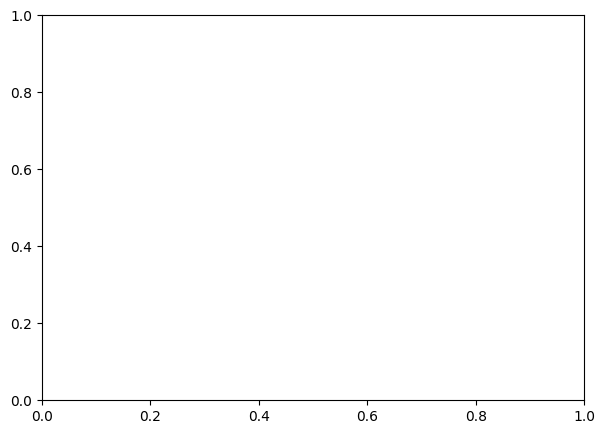

In [17]:
# dataset_names = ['BITCOIN', 'UCI', 'MOOC', 'WIKI']

# for dataset_name in dataset_names:
#     plot_continuous_network(raw_path=None, network_name=dataset_name)


dataset_name = 'BITCOIN'
plot_continuous_network(raw_path=None, network_name=dataset_name)
